# Image Classifier

In [1]:
import os
import io
import zipfile
import shutil
from os import listdir

import requests
from PIL import Image
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os, random, shutil
from pathlib import Path

from tensorflow.keras import Sequential
from tensorflow.keras.utils import set_random_seed
from tensorflow.keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

2025-09-27 21:28:39.660745: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-09-27 21:28:39.739604: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-27 21:28:43.211888: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-09-27 21:28:54.170237: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

In [2]:
url = "https://storage.googleapis.com/datascience-materials/dogs-vs-cats.zip"
response = requests.get(url)
response.raise_for_status()

ZIP_ROOT = "dogs-vs-cats"
with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    z.extractall(ZIP_ROOT)

BASE = os.path.join(ZIP_ROOT, "dogs-vs-cats")
TRAIN_DIR = os.path.join(BASE, "train")

# Organizing dataset into class subfolders

In [3]:
cat_dir = os.path.join(TRAIN_DIR, "cat")
dog_dir = os.path.join(TRAIN_DIR, "dog")
os.makedirs(cat_dir, exist_ok=True)
os.makedirs(dog_dir, exist_ok=True)

for fname in listdir(TRAIN_DIR):
    src_path = os.path.join(TRAIN_DIR, fname)
    if not os.path.isfile(src_path):
        continue
    
    if fname.startswith("cat."):
        dst = os.path.join(cat_dir, fname)
    elif fname.startswith("dog."):
        dst = os.path.join(dog_dir, fname)
    else:
        continue  
    if not os.path.exists(dst):
        shutil.move(src_path, dst)

## Visualizing the information

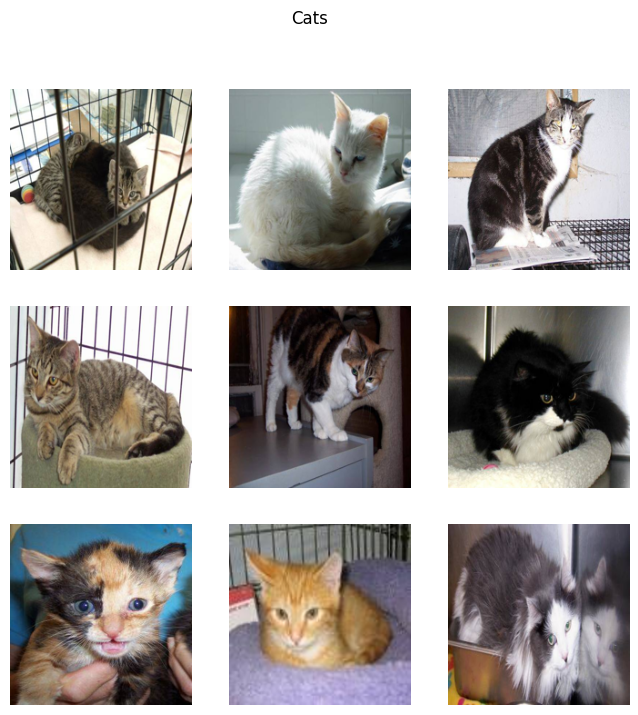

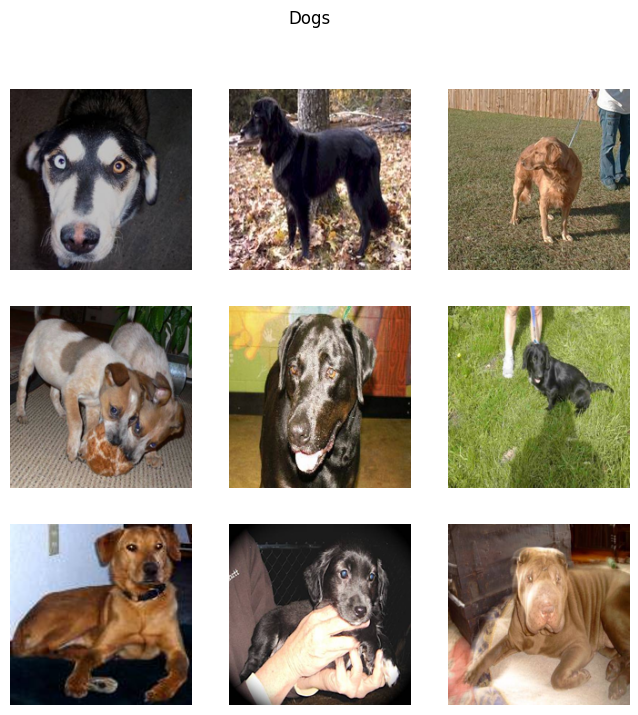

In [4]:
img_size = (200, 200)

def printing_cats():
    cats_dir = os.path.join(TRAIN_DIR, "cat")
    images_cats = os.listdir(cats_dir)[:9]
    plt.figure(figsize=(8,8))
    for i, name in enumerate(images_cats):
        img = Image.open(os.path.join(cats_dir, name)).resize(img_size)
        plt.subplot(3,3,i+1); plt.imshow(img); plt.axis("off")
    plt.suptitle("Cats")
    plt.show()

def printing_dogs():
    dogs_dir = os.path.join(TRAIN_DIR, "dog")
    images_dogs = os.listdir(dogs_dir)[:9]
    plt.figure(figsize=(8,8))
    for i, name in enumerate(images_dogs):
        img = Image.open(os.path.join(dogs_dir, name)).resize(img_size)
        plt.subplot(3,3,i+1); plt.imshow(img); plt.axis("off")
    plt.suptitle("Dogs")
    plt.show()

printing_cats()
printing_dogs()

# Splitting into train and validation

In [5]:
random.seed(42)

datagen_train = ImageDataGenerator(rescale=1./255, validation_split=0.2)
datagen_val   = ImageDataGenerator(rescale=1./255, validation_split=0.2)

trdata = datagen_train.flow_from_directory(
    TRAIN_DIR,
    target_size=img_size,
    batch_size=64,            
    class_mode="binary",
    subset="training",
    shuffle=True,
    seed=42
)

tsdata = datagen_val.flow_from_directory(
    TRAIN_DIR,
    target_size=img_size,
    batch_size=64,
    class_mode="binary",
    subset="validation",
    shuffle=False
)

print(trdata.class_indices) 

Found 20000 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.
{'cat': 0, 'dog': 1}


# Building the CNN model

In [ ]:
set_random_seed(42)

model = Sequential([
    Conv2D(32, 3, padding="same", activation="relu", input_shape=(200,200,3)),
    Conv2D(32, 3, padding="same", activation="relu"),
    MaxPooling2D(),
    
    Conv2D(64, 3, padding="same", activation="relu"),
    Conv2D(64, 3, padding="same", activation="relu"),
    MaxPooling2D(),

    GlobalAveragePooling2D(),
    Dropout(0.2),
    Dense(1, activation="sigmoid")
])

model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model.summary()

/home/vscode/.local/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-09-27 21:30:09.436769: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 200, 200, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 200, 200, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 100, 100, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 100, 100, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 100, 100, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 50, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,633 (256.38 KB)

 Trainable params: 65,633 (256.38 KB)

 Non-trainable params: 0 (0.00 B)

: 

# Training the model

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

callbacks = [
    EarlyStopping(monitor="val_loss", patience=1, restore_best_weights=True),
    ModelCheckpoint("cats_dogs_best.keras", monitor="val_loss", save_best_only=True),
]

history = model.fit(
    trdata,
    validation_data=tsdata,
    epochs=2,              
    steps_per_epoch=20,    
    validation_steps=5,    
    callbacks=callbacks
)

/home/vscode/.local/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/2
20/20 ━━━━━━━━━━━━━━━━━━━━ 118s 6s/step - accuracy: 0.5216 - loss: 0.6932 - val_accuracy: 0.0219 - val_loss: 0.7405
Epoch 2/2


# Measuring performance

In [ ]:
loss, acc = model.evaluate(tsdata, steps=5)
print(f"Validation loss: {loss:.4f}, Validation accuracy: {acc:.4f}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 996ms/step - accuracy: 0.3500 - loss: 0.6979
Validation loss: 0.6979, Validation accuracy: 0.3500


# Saving the model

In [ ]:
os.makedirs("../models", exist_ok=True)
model.save("../models/cats_dogs_final.keras")

# Final Conclusions:

### In this project I built a basic image classifier to separate cats and dogs. I followed the instructions step by step: first I downloaded and organized the dataset, then I visualized some examples, resized all images to 200x200, and used ImageDataGenerator to prepare the data. After that I created a CNN model inspired by the VGG16 structure, trained it with early stopping and checkpoints, evaluated the results, and finally saved the model.

### The results were limited because training this type of model was very slow on my computer. Because of this, I couldn’t really train for many epochs or try deeper architectures, so the accuracy stayed lower than what I would expect from stronger hardware.